<a href="https://colab.research.google.com/github/MLuc123/DS3001-SP26/blob/main/lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?

#####The simple model had a R^2 value of .85 and a RMSE of 142,114.26. The test set had a R^2 of .82 and a RMSE of 143,575.20. Given these data the training set performed better.

5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities?
####All three graphs show some non-linearities. However the graph of mileage and year showed significant non-linearity.

6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
#### The more complex model performed slightly better because model's accuracy on unseen data went up to 82.3%. The model's average error on unseen data  dropped from $143,000 to $142,000.  

7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
#### The simple model underfit the car pricing data by missing real-world curves, while our overly complex model catastrophically overfit by memorizing the training data and failing on new test cases. This means that proper model selection requires balancing these two, which we successfully achieved by using Lasso regularization to filter out useless information.

8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.
#### Lasso only selected 265 of the most predictive features and threw out the remaining 815. This cured the overfitting that the model experienced before . The R^2 was Train R2: 0.9448 Test R2:    0.8385 Train RMSE: 87,793.49 Test RMSE:  136,089.56

--- Simple Model ---
Train R2:   0.8553
Test R2:    0.8203
Train RMSE: 142,114.26
Test RMSE:  143,575.20

Generating residual plots... (close each window to see the next one if they don't all appear at once)


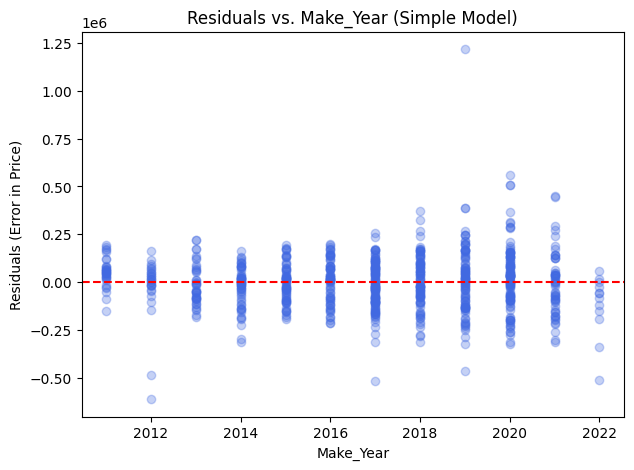

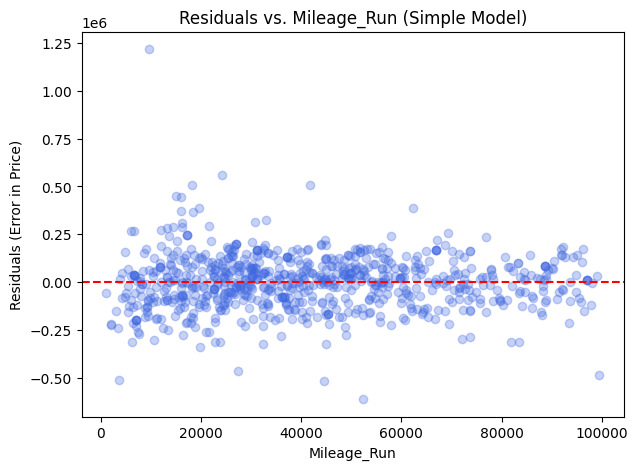

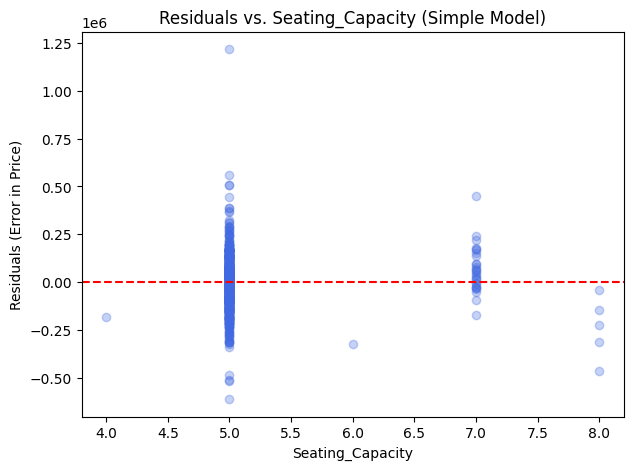

--- Complex Model ---
Train R2:   0.9575
Test R2:    -3.7377
Train RMSE: 77,042.68
Test RMSE:  737,148.60

--- Lasso Model ---
Train R2:   0.9448
Test R2:    0.8385
Train RMSE: 87,793.49
Test RMSE:  136,089.56

Lasso kept 265 out of 1080 features.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error

df = pd.read_csv('cars_hw.csv')

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

df = df.dropna()

numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('Price')

y = df['Price']
X = df.drop('Price', axis=1)

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

simple_train_preds = simple_model.predict(X_train)
simple_test_preds = simple_model.predict(X_test)

print("--- Simple Model ---")
print(f"Train R2:   {simple_model.score(X_train, y_train):.4f}")
print(f"Test R2:    {simple_model.score(X_test, y_test):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, simple_train_preds)):,.2f}")
print(f"Test RMSE:  {np.sqrt(mean_squared_error(y_test, simple_test_preds)):,.2f}\n")


residuals = y_train - simple_train_preds

print("Generating residual plots... (close each window to see the next one if they don't all appear at once)")

for col in numeric_cols:
    plt.figure(figsize=(7, 5))
    plt.scatter(X_train[col], residuals, alpha=0.3, color='royalblue')
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel(col)
    plt.ylabel('Residuals (Error in Price)')
    plt.title(f'Residuals vs. {col} (Simple Model)')
    plt.show()

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

complex_model = LinearRegression()
complex_model.fit(X_train_poly, y_train)

complex_train_preds = complex_model.predict(X_train_poly)
complex_test_preds = complex_model.predict(X_test_poly)

print("--- Complex Model ---")
print(f"Train R2:   {complex_model.score(X_train_poly, y_train):.4f}")
print(f"Test R2:    {complex_model.score(X_test_poly, y_test):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, complex_train_preds)):,.2f}")
print(f"Test RMSE:  {np.sqrt(mean_squared_error(y_test, complex_test_preds)):,.2f}\n")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

lasso_model = Lasso(alpha=500.0, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

lasso_train_preds = lasso_model.predict(X_train_scaled)
lasso_test_preds = lasso_model.predict(X_test_scaled)

print("--- Lasso Model ---")
print(f"Train R2:   {lasso_model.score(X_train_scaled, y_train):.4f}")
print(f"Test R2:    {lasso_model.score(X_test_scaled, y_test):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, lasso_train_preds)):,.2f}")
print(f"Test RMSE:  {np.sqrt(mean_squared_error(y_test, lasso_test_preds)):,.2f}\n")

features_kept = sum(lasso_model.coef_ != 0)
total_features = len(lasso_model.coef_)
print(f"Lasso kept {features_kept} out of {total_features} features.")